In [1]:
### COLAB SETUP

%cd /content
!rm -rf /content/proto-tsrl
!git clone https://github.com/haiyan-wang/proto-tsrl.git /content/proto-tsrl
%cd /content/proto-tsrl

from google.colab import drive, runtime
drive.mount('/content/drive')

import sys
import os

project_root = os.getcwd()
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(project_root)

/content
Cloning into '/content/proto-tsrl'...
remote: Enumerating objects: 621, done.
remote: Counting objects: 100% (228/228), done.
remote: Compressing objects: 100% (178/178), done.
remote: Total 621 (delta 129), reused 102 (delta 50), pack-reused 393 (from 1)
Receiving objects: 100% (621/621), 18.96 MiB | 24.45 MiB/s, done.
Resolving deltas: 100% (342/342), done.
/content/proto-tsrl
Mounted at /content/drive
/content/proto-tsrl


In [2]:
!pip install pacmap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 144.0 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torch.nn as nn
import torch.nn.functional as F

from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight, compute_class_weight

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix

import pacmap

from src.utils.training_utils import _pairwise_cos_sim, _extended_forward
from src.utils.sampling_utils import TimeSeriesDataset
from src.experiments.synthetic_univariate.univariate_model import UnivariateModel

In [4]:
### SETTINGS

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# device
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(DEVICE)

# data
TRAIN_SET_SIZE = int(1e4)
TEST_SET_SIZE = int(1e3)

# logging
SAVE_DIR = "/content/drive/MyDrive/Duke/Senior Year/Thesis/experiments/autoregressive_univariate"

# architecture
REPR_DIMS = [300]
MODELS = {}
for dim in REPR_DIMS:
    model_list = {}

    ckpt_dir = f"{SAVE_DIR}/checkpoints/dim{dim}"
    for ckpt_file in os.listdir(ckpt_dir):
        epoch = ckpt_file[10:-3]
        ckpt = torch.load(f"{ckpt_dir}/{ckpt_file}", map_location = "cpu")
        MODEL = UnivariateModel(representation_dimension = dim)
        MODEL.load_state_dict(ckpt)
        MODEL = MODEL.to(DEVICE)
        if torch.cuda.device_count() > 1:
            MODEL = nn.DataParallel(MODEL)
        MODEL.eval()

        model_list[epoch] = MODEL

    MODELS[dim] = model_list

cuda:0


In [ ]:
### LOAD DATA

with np.load("/content/drive/MyDrive/Duke/Senior Year/Thesis/autoregressive_data/autoregressive.npz", allow_pickle = True) as data:
    series = list(data["series"])
y = np.loadtxt("/content/drive/MyDrive/Duke/Senior Year/Thesis/autoregressive_data/autoregressive_labels.csv", delimiter = ',')

# shuffle
rng = np.random.default_rng(SEED)
idx = rng.permutation(len(series))
series = [series[i] for i in idx]
y = y[idx]

# split
X_train = series[:TRAIN_SET_SIZE]
y_train = y[:TRAIN_SET_SIZE]
X_test = series[TRAIN_SET_SIZE:TRAIN_SET_SIZE+TEST_SET_SIZE]
y_test = y[TRAIN_SET_SIZE:TRAIN_SET_SIZE+TEST_SET_SIZE]

ds_train, ds_test = TimeSeriesDataset(X_train), TimeSeriesDataset(X_test)

dl_train = DataLoader(
    ds_train,
    batch_size = 1,
    shuffle = False,
    num_workers = 4,
    pin_memory = True
)

dl_test = DataLoader(
    ds_test,
    batch_size = 1,
    shuffle = False,
    num_workers = 4,
    pin_memory = True,
)

In [ ]:
### GENERATE REPRESENTATIONS

with torch.inference_mode():

    for dim in REPR_DIMS:
        model = MODELS[dim]['epoch55']

        train_reprs = []
        for x in dl_train:
            x = x.permute(0, 2, 1)
            x = x.to(DEVICE)
            repr = model(x).cpu().numpy()
            train_reprs.append(repr)
        train_reprs_numpy = np.concatenate(train_reprs, axis = 0)
        np.savetxt(f'{SAVE_DIR}/test_reprs/prototsrl{dim}-repr-train.csv', train_reprs_numpy, delimiter = ',')

        test_reprs = []
        for x in dl_test:
            x = x.permute(0, 2, 1)
            x = x.to(DEVICE)
            repr = model(x).cpu().numpy()
            test_reprs.append(repr)
        test_reprs_numpy = np.concatenate(test_reprs, axis = 0)
        np.savetxt(f'{SAVE_DIR}/test_reprs/prototsrl{dim}-repr-test.csv', test_reprs_numpy, delimiter = ',')

In [ ]:
### LOAD TRAIN AND TEST SET REPRESENTATIONS AND CREATE DATALOADERS

repr = {}
for dim in REPR_DIMS:
    repr[dim] = {}
    for repr_set in ['train', 'test']:
        repr[dim][repr_set] = pd.read_csv(f'{SAVE_DIR}/test_reprs/prototsrl{dim}-repr-{repr_set}.csv', header = None).values

# Convert to tensors
y_tensors = {}
y_tensors['train'] = torch.tensor(y_train, dtype = torch.float32)
y_tensors['test'] = torch.tensor(y_test, dtype = torch.float32)

repr_loaders = {}
for dim in REPR_DIMS:
    repr_loaders[dim] = {}
    for repr_set in ['train', 'test']:
        X_tensor = torch.tensor(repr[dim][repr_set], dtype = torch.float32)
        X_dataset = TensorDataset(X_tensor, y_tensors[repr_set])
        if repr_set == 'train':
            repr_loaders[dim][repr_set] = DataLoader(X_dataset, batch_size = 256, shuffle = True)
        else:
            repr_loaders[dim][repr_set] = DataLoader(X_dataset, batch_size = X_tensor.size(0), shuffle = False)

# Classification Tasks

In [ ]:
# MLP

class mlp_clf(nn.Module):
    def __init__(self, input_dim, n_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, input_dim*2),
            nn.ReLU(),
            nn.Linear(input_dim*2, input_dim*4),
            nn.ReLU(),
            nn.Linear(input_dim*4, n_classes)
        )

    def forward(self, x):
        return self.net(x)  # logits

def mlpclf_train(
        model,
        dataloader,
        device,
        criterion,
        optimizer,
        n_epochs,
        log_interval = 10
    ):

    for epoch in range(n_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for xb, yb in dataloader:
            xb = xb.to(device)
            yb = yb.to(device).long()

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * xb.size(0)

            preds = torch.argmax(logits, dim = 1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

        epoch_loss = running_loss / len(dataloader.dataset)
        epoch_acc = correct / total

        if (epoch + 1) % log_interval == 0:
            print(
                f"Epoch {epoch+1:02d}/{n_epochs} - "
                f"Train Loss: {epoch_loss:.4f} - "
                f"Train Acc: {epoch_acc:.4f}"
            )


def mlpclf_eval(
        model,
        dataloader,
        device
    ):

    model.eval()

    all_preds = []
    all_targets = []
    all_probs = []

    with torch.no_grad():
        for xb, yb in dataloader:
            xb = xb.to(device)
            yb = yb.to(device).long()

            logits = model(xb)
            probs = torch.softmax(logits, dim = 1)
            preds = torch.argmax(logits, dim = 1)

            all_probs.append(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(yb.cpu().numpy())

    all_probs = np.vstack(all_probs)
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)

    print(f"Accuracy          : {accuracy_score(all_targets, all_preds):.4f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(all_targets, all_preds))

In [ ]:
mlps = {}
opts = {}
for dim in REPR_DIMS:
    mlps[dim] = mlp_clf(input_dim = dim, n_classes = 3).to(DEVICE)
    opts[dim] = torch.optim.Adam(mlps[dim].parameters(), lr = 1e-3)

criterion = nn.CrossEntropyLoss()

In [ ]:
print('===== 300D =====')
mlpclf_train(
    model = mlps[300],
    dataloader = repr_loaders[300]['train'],
    device = DEVICE,
    criterion = criterion,
    optimizer = opts[300],
    n_epochs = 100
)

===== 300D =====
Epoch 10/100 - Train Loss: 0.0001 - Train Acc: 1.0000
Epoch 20/100 - Train Loss: 0.0000 - Train Acc: 1.0000
Epoch 30/100 - Train Loss: 0.0000 - Train Acc: 1.0000
Epoch 40/100 - Train Loss: 0.0000 - Train Acc: 1.0000
Epoch 50/100 - Train Loss: 0.0000 - Train Acc: 1.0000
Epoch 60/100 - Train Loss: 0.0000 - Train Acc: 1.0000
Epoch 70/100 - Train Loss: 0.0000 - Train Acc: 1.0000
Epoch 80/100 - Train Loss: 0.0000 - Train Acc: 1.0000
Epoch 90/100 - Train Loss: 0.0000 - Train Acc: 1.0000
Epoch 100/100 - Train Loss: 0.0000 - Train Acc: 1.0000


In [ ]:
print('===== 300D =====')
mlpclf_eval(
    model = mlps[300],
    dataloader = repr_loaders[300]['test'],
    device = DEVICE
)

===== 300D =====
Accuracy          : 1.0000

Confusion Matrix:
[[350   0   0]
 [  0 333   0]
 [  0   0 317]]


# Prototype Evolution

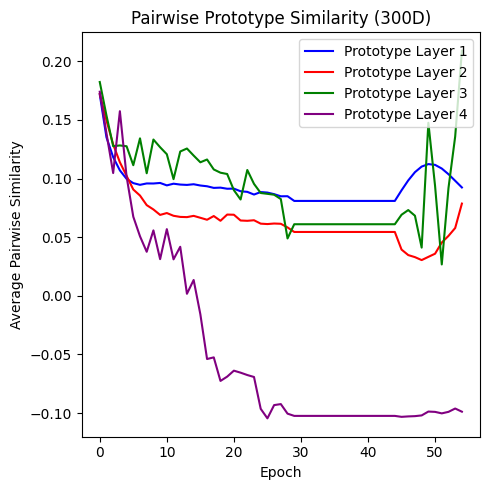

In [8]:
@torch.no_grad()
def prototype_evolution(dim, n_prototype_layers):

    epoch_sims = [[] for _ in range(n_prototype_layers)]

    for epoch, m in MODELS[dim].items():
        if isinstance(m, nn.DataParallel):
            model = m.module
        else:
            model = m

        epoch_num = int(epoch[5:])

        for layer_idx, prototype_layer in enumerate(model.prototype_layers):
            prototype_vectors = prototype_layer.prototype_vectors
            sim = _pairwise_cos_sim(prototype_vectors, prototype_vectors, eps = 1e-8)

            n = sim.size(0)
            if n < 2:
                return sim.new_tensor(0.0)

            off_diag_mask = ~torch.eye(n, dtype = torch.bool, device = sim.device)
            off_diag = sim[off_diag_mask]
            epoch_sims[layer_idx].append(off_diag.mean().cpu())

    return epoch_sims

fig, ax = plt.subplots(1, 1, figsize = (5*len(REPR_DIMS), 5), tight_layout = True)

for i, dim in enumerate(REPR_DIMS):
    sims = prototype_evolution(dim, 4)
    colors = ['blue', 'red', 'green', 'purple']

    for layer_idx, layer_sims in enumerate(sims):
        ax.plot(layer_sims, color = colors[layer_idx], label = f'Prototype Layer {layer_idx + 1}')

    ax.set_title(f'Pairwise Prototype Similarity ({dim}D)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Average Pairwise Similarity')
    ax.legend(loc = 'upper right')

# Dimension Reduced Intermediate Representations

In [ ]:
dr_epochs = [35, 40, 45, 50, 55]

with torch.inference_mode():
    for dim in REPR_DIMS:
        for epoch in dr_epochs:
            model = MODELS[dim][f'epoch{epoch}']
            reprs = []
            for batch in dl_test:
                x = batch.permute(0, 2, 1)
                x = x.to(DEVICE)
                repr = model(x).cpu().numpy()
                reprs.append(repr)
            reprs_numpy = np.concatenate(reprs, axis = 0)
            np.savetxt(f'{SAVE_DIR}/test_reprs/prototsrl{dim}-epoch{epoch}-repr-test.csv', reprs_numpy, delimiter = ',')

In [ ]:
embs = {}

pm = pacmap.PaCMAP(n_components = 3)
for dim in REPR_DIMS:
    embs[dim] = {}
    for epoch in dr_epochs:
        repr = pd.read_csv(f'{SAVE_DIR}/test_reprs/prototsrl{dim}-epoch{epoch}-repr-test.csv', header = None)
        emb = pm.fit_transform(repr)
        embs[dim][epoch] = emb

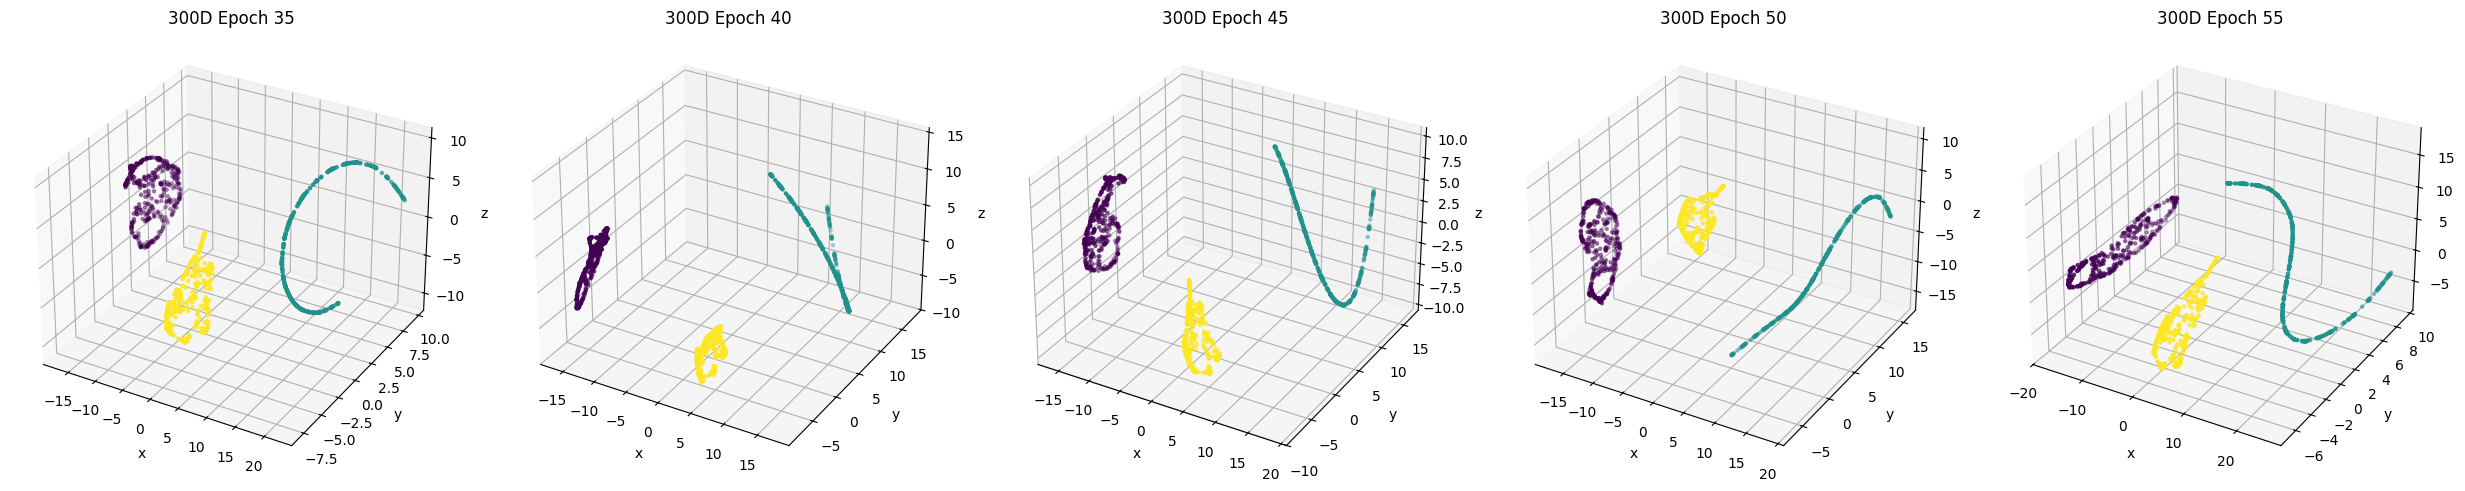

In [ ]:
fig, axs = plt.subplots(
    1, 5,
    figsize = (25, 5),
    tight_layout = True,
    subplot_kw = {"projection": "3d"}
)

for dim in REPR_DIMS:
    for col, epoch in enumerate(dr_epochs):
        emb = embs[dim][epoch]
        ax = axs[col]

        ax.scatter(
            emb[:, 0],
            emb[:, 1],
            emb[:, 2],
            s = 5,
            c = y_test
        )

        ax.set_title(f"{dim}D Epoch {epoch}")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_zlabel("z")

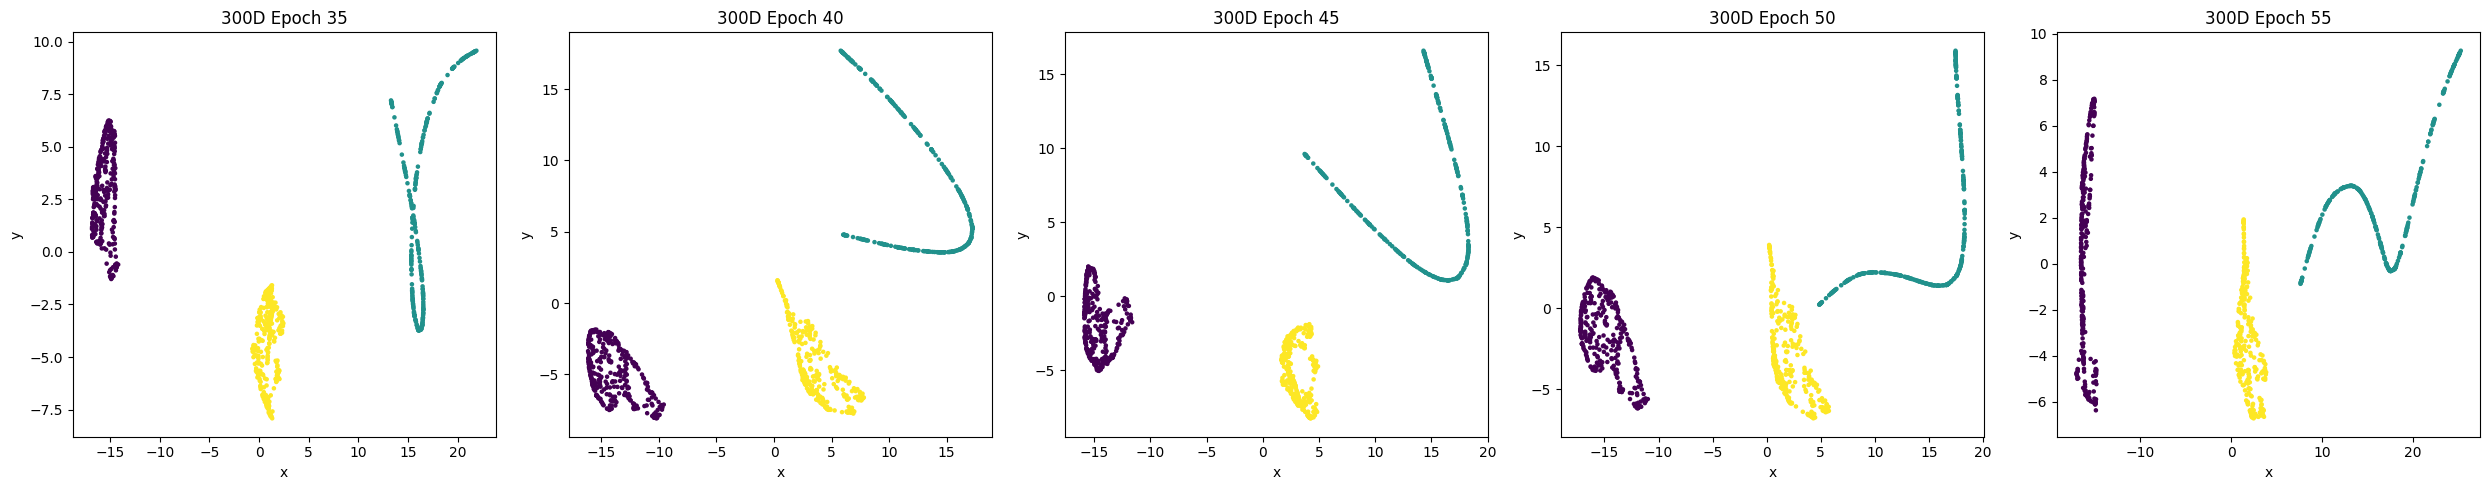

In [ ]:
fig, axs = plt.subplots(1, 5, figsize = (25, 5), tight_layout = True)

for dim in REPR_DIMS:
    for col, epoch in enumerate(dr_epochs):
        emb = embs[dim][epoch]

        ax = axs[col]
        ax.scatter(emb[:,0], emb[:,1], s = 5, c = y_test)
        ax.set_title(f"{dim}D Epoch {epoch}")
        ax.set_xlabel("x")
        ax.set_ylabel("y")

# Activation Maps

In [ ]:
@torch.no_grad()
def get_prototype_activations(model, x, device):

    model.eval()
    x = x.to(device)
    out = _extended_forward(model, x)

    return out["a"]

@torch.no_grad()
def overlay_prototype_activation(model, x, proto_layer_idx, proto_idx, device):

    acts = get_prototype_activations(model, x, device)
    a = acts[proto_layer_idx][0, proto_idx]   # [T_layer]

    signal = x[0, 0].detach().cpu()           # univariate PPG
    T = signal.shape[0]

    # upsample activation trace to raw signal length
    a_up = F.interpolate(a[None, None, :], size = T, mode = "linear", align_corners = False)[0, 0].cpu()

    # normalize for display
    a_up = (a_up - a_up.min()) / (a_up.max() - a_up.min() + 1e-8)

    fig, ax = plt.subplots(figsize=(12, 3))
    ax.plot(signal.numpy(), linewidth=1.0)

    # translucent heat band
    ax.fill_between(
        range(T),
        signal.min().item(),
        signal.max().item(),
        where = (a_up.numpy() > 0.5),
        alpha = 0.2,
        step = None
    )

    # also plot the activation trace on a second axis
    ax2 = ax.twinx()
    ax2.plot(a_up.numpy(), linewidth=1.0)
    ax2.set_ylim(0, 1)

    ax.set_title(f"Prototype layer {proto_layer_idx+1}, prototype {proto_idx}")
    plt.show()